In [1]:
import csv
import math
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:

FRAME_RATE = 75

# Keep 10 seconds for this capacity experiment.
SEGMENT_SECONDS = 10.0
SEGMENT_FRAMES = int(SEGMENT_SECONDS * FRAME_RATE)

# Training data / loader config
BATCH_SIZE = 24
NUM_WORKERS = 2
SAMPLES_PER_TRACK = 20   # more crops per track
SAVE_EVERY_BATCHES = 25
NUM_EPOCHS = 30          # increased from 25 to 30
EARLY_STOPPING_PATIENCE = 4


EMBEDDING_DIM = 448
NUM_LAYERS = 14
NUM_HEADS = 8
FEEDFORWARD_DIM = 2304
DROPOUT = 0.10

# Codec / sequence config (must match your tensors)
NUM_CODEBOOKS = 8
CODEBOOK_SIZE = 1024       # valid codes: 0..1023
PAD_TOKEN_ID = 1024        # EnCodec PAD, must match your tensors
FRAME_RATE = 75            # Hz
SEGMENT_SECONDS = 10.0
SEGMENT_FRAMES = int(round(SEGMENT_SECONDS * FRAME_RATE))
# LR for OST finetuning (smaller than Slakh finetune)
PEAK_LR = 1e-5      # reduced from 5e-5
MIN_LR = 3e-6       # reduced from 1e-5
WARMUP_STEPS = 200  # shorter warmup for small dataset


WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0
MAX_SEQUENCE_LENGTH = SEGMENT_FRAMES + NUM_CODEBOOKS - 1

# Aggressive, let's push down later codebooks
CODEBOOK_LOSS_WEIGHTS = torch.tensor(
    [1.0, 1.0, 2.0, 2.0, 2.5, 2.5, 2.5, 2.5],
    dtype=torch.float32,
    device=device,
)


# STEPS_PER_EPOCH = len(train_loader)
# TOTAL_TRAINING_STEPS = NUM_EPOCHS * STEPS_PER_EPOCH

# # MAX_STEPS must reflect the real number of training steps,
# # not an arbitrary fixed number.
# MAX_STEPS = TOTAL_TRAINING_STEPS

In [3]:
class SecundaAudioDataset(Dataset):
    def __init__(
        self,
        manifest_path,
        source_roots,
        split="train",
        stage=None,
        segment_seconds=5.0,
        frame_rate=75,
        fixed_start=False,
        seed=42,
        samples_per_track=1,
    ):
        self.manifest_path = Path(manifest_path)

        self.source_roots = {
            key: Path(value)
            for key, value in source_roots.items()
        }

        self.segment_frames = int(
            round(segment_seconds * frame_rate)
        )

        if self.segment_frames < 2:
            raise ValueError(
                "segment_seconds must produce at least 2 frames."
            )

        if samples_per_track < 1:
            raise ValueError(
                "samples_per_track must be at least 1."
            )

        self.fixed_start = fixed_start
        self.seed = seed
        self.epoch = 0
        self.samples_per_track = samples_per_track

        with open(
            self.manifest_path,
            newline="",
            encoding="utf-8",
        ) as file:
            all_rows = list(csv.DictReader(file))

        self.rows = [
            row
            for row in all_rows
            if row["split"] == split
            and row["split"] != "excluded"
            and (
                stage is None
                or row["stage"] == stage
            )
        ]

        if not self.rows:
            raise ValueError(
                f"No rows found for split={split}, stage={stage}"
            )

        self._validate_rows()

    def _validate_rows(self):
        for row in self.rows:
            source = row["source"]

            if source not in self.source_roots:
                raise KeyError(
                    f"No root configured for source={source}"
                )

            filename = Path(row["path"]).name
            tensor_path = self.source_roots[source] / filename

            if not tensor_path.exists():
                raise FileNotFoundError(tensor_path)

            if int(row["num_codebooks"]) != 32:
                raise ValueError(
                    f"{tensor_path}: expected 32 codebooks"
                )

            if int(row["frame_rate"]) != 75:
                raise ValueError(
                    f"{tensor_path}: expected 75 fps"
                )

            if float(row["bandwidth_kbps"]) != 24.0:
                raise ValueError(
                    f"{tensor_path}: expected 24 kbps"
                )

            if int(row["num_frames"]) < self.segment_frames:
                raise ValueError(
                    f"{tensor_path}: has only "
                    f"{row['num_frames']} frames, but needs "
                    f"{self.segment_frames}"
                )

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __len__(self):
        return len(self.rows) * self.samples_per_track

    def _path_for_row(self, row):
        source = row["source"]
        filename = Path(row["path"]).name
        return self.source_roots[source] / filename

    def _choose_start(self,row_index,crop_index,total_frames,):
        max_start = total_frames - self.segment_frames
    
        if max_start <= 0:
            return 0
    
        if self.fixed_start:
            # Validation:
            # same interior crop for this validation track every epoch.
            # It is deterministic, but not forced to begin at frame 0.
            generator = random.Random(
                self.seed
                + 99_999_937
                + row_index * 10_000
                + crop_index
            )
        else:
            # Training:
            # deterministic but changes with epoch.
            generator = random.Random(
                self.seed
                + self.epoch * 1_000_000
                + row_index * 10_000
                + crop_index
            )
    
        return generator.randint(0, max_start)



    def __getitem__(self, index):
        row_index = index // self.samples_per_track
        crop_index = index % self.samples_per_track

        row = self.rows[row_index]
        tensor_path = self._path_for_row(row)

        data = torch.load(
            tensor_path,
            map_location="cpu",
            weights_only=False,
        )

        tokens = data["tokens"].long()
        tension = data["tension"].float()
        combat_score = data["combat_score"].float()

        if tokens.ndim != 2:
            raise ValueError(
                f"{tensor_path}: tokens must be [n_q, T]"
            )

        total_frames = tokens.shape[-1]

        if total_frames != len(tension):
            raise ValueError(
                f"{tensor_path}: tokens/tension mismatch"
            )

        if total_frames != len(combat_score):
            raise ValueError(
                f"{tensor_path}: tokens/combat mismatch"
            )

        start = self._choose_start(
            row_index=row_index,
            crop_index=crop_index,
            total_frames=total_frames,
        )

        end = start + self.segment_frames

        return {
            "tokens": tokens[:NUM_CODEBOOKS, start:end],
            "tension": tension[start:end],
            "combat_score": combat_score[start:end],
            "source": row["source"],
            "track_id": row["track_id"],
            "path": row["path"],
            "start_frame": start,
            "crop_index": crop_index,
        }



In [4]:
# frame codec delay


NUM_CODEBOOKS = 8
CODEBOOK_SIZE = 1024
PAD_TOKEN_ID = CODEBOOK_SIZE
MODEL_VOCAB_SIZE = CODEBOOK_SIZE + 1


def validate_code_tensor(
    codes,
    num_codebooks=NUM_CODEBOOKS,
    codebook_size=CODEBOOK_SIZE,
):
    if codes.ndim != 3:
        raise ValueError(
            "Expected codes shaped [batch, num_codebooks, time], "
            f"got {tuple(codes.shape)}"
        )

    if codes.shape[1] != num_codebooks:
        raise ValueError(
            f"Expected {num_codebooks} codebooks, "
            f"got {codes.shape[1]}"
        )

    if codes.numel() == 0:
        raise ValueError("Code tensor is empty.")

    minimum = int(codes.min())
    maximum = int(codes.max())

    if minimum < 0 or maximum >= codebook_size:
        raise ValueError(
            f"Code IDs must lie in [0, {codebook_size - 1}], "
            f"but found min={minimum}, max={maximum}."
        )


def validate_condition_tensor(condition, name, batch_size, time_steps):
    if condition.ndim != 2:
        raise ValueError(
            f"{name} must be shaped [batch, time], "
            f"got {tuple(condition.shape)}"
        )

    expected_shape = (batch_size, time_steps)

    if tuple(condition.shape) != expected_shape:
        raise ValueError(
            f"{name} must have shape {expected_shape}, "
            f"got {tuple(condition.shape)}"
        )


class CodebookSerializer:
    """
    Implements the diagonal delayed-codebook pattern.

    Input:
        codes: [B, Q, T]

    Output:
        delayed_codes: [B, Q, T + Q - 1]

    Codebook q is delayed by q positions:
        delayed_codes[:, q, q:q+T] = codes[:, q, :]

    Empty positions receive PAD_TOKEN_ID = 1024.
    """

    def __init__(
        self,
        num_codebooks=NUM_CODEBOOKS,
        codebook_size=CODEBOOK_SIZE,
        pad_token_id=PAD_TOKEN_ID,
    ):
        self.num_codebooks = num_codebooks
        self.codebook_size = codebook_size
        self.pad_token_id = pad_token_id

        if pad_token_id < codebook_size:
            raise ValueError(
                "PAD token must not overlap valid EnCodec IDs."
            )

    @property
    def model_vocab_size(self):
        return self.pad_token_id + 1

    def delay(self, codes):
        validate_code_tensor(
            codes,
            num_codebooks=self.num_codebooks,
            codebook_size=self.codebook_size,
        )

        batch_size, _, time_steps = codes.shape
        delayed_time = time_steps + self.num_codebooks - 1

        delayed_codes = torch.full(
            (
                batch_size,
                self.num_codebooks,
                delayed_time,
            ),
            fill_value=self.pad_token_id,
            dtype=codes.dtype,
            device=codes.device,
        )

        for codebook_index in range(self.num_codebooks):
            start = codebook_index
            end = start + time_steps

            delayed_codes[
                :,
                codebook_index,
                start:end,
            ] = codes[:, codebook_index, :]

        return delayed_codes

    def undelay(self, delayed_codes):
        if delayed_codes.ndim != 3:
            raise ValueError(
                "Expected delayed codes shaped [B, Q, S], "
                f"got {tuple(delayed_codes.shape)}"
            )

        batch_size, found_codebooks, delayed_time = delayed_codes.shape

        if found_codebooks != self.num_codebooks:
            raise ValueError(
                f"Expected {self.num_codebooks} codebooks, "
                f"got {found_codebooks}."
            )

        original_time = delayed_time - self.num_codebooks + 1

        if original_time <= 0:
            raise ValueError(
                "Delayed sequence is too short to recover codes."
            )

        recovered_codes = torch.empty(
            (
                batch_size,
                self.num_codebooks,
                original_time,
            ),
            dtype=delayed_codes.dtype,
            device=delayed_codes.device,
        )

        for codebook_index in range(self.num_codebooks):
            start = codebook_index
            end = start + original_time

            recovered_codes[
                :,
                codebook_index,
                :,
            ] = delayed_codes[
                :,
                codebook_index,
                start:end,
            ]

        validate_code_tensor(
            recovered_codes,
            num_codebooks=self.num_codebooks,
            codebook_size=self.codebook_size,
        )

        return recovered_codes


def delay_conditions_by_codebook(tension, combat_score, num_codebooks=NUM_CODEBOOKS, pad_value=0.0):
    """
    Aligns time-varying controls to the staggered codebook targets.
    
    Inputs:
        tension, combat_score: [B, T]
        
    Outputs:
        delayed_tension: [B, Q, T + Q - 1]
        delayed_combat:  [B, Q, T + Q - 1]
        valid_mask:      [B, Q, T + Q - 1] (True where real audio exists)
    """
    batch_size, original_time = tension.shape
    delayed_time = original_time + num_codebooks - 1

    # Initialize with a pad value (e.g., 0.0). These positions will be ignored in the loss.
    delayed_tension = torch.full(
        (batch_size, num_codebooks, delayed_time), 
        pad_value, dtype=tension.dtype, device=tension.device
    )
    delayed_combat = torch.full(
        (batch_size, num_codebooks, delayed_time), 
        pad_value, dtype=combat_score.dtype, device=combat_score.device
    )
    valid_mask = torch.zeros(
        (batch_size, num_codebooks, delayed_time), 
        dtype=torch.bool, device=tension.device
    )

    for q in range(num_codebooks):
        start = q
        end = q + original_time
        delayed_tension[:, q, start:end] = tension
        delayed_combat[:, q, start:end] = combat_score
        valid_mask[:, q, start:end] = True

    return delayed_tension, delayed_combat, valid_mask


def prepare_next_frame_batch(batch, serializer=None):
    """
    Updated to return codebook-aligned conditions.
    """
    if serializer is None:
        serializer = CodebookSerializer()

    tokens = batch["tokens"].long()
    tension = batch["tension"].float()
    combat_score = batch["combat_score"].float()

    delayed_codes = serializer.delay(tokens)
    delayed_tension, delayed_combat, valid_mask = delay_conditions_by_codebook(
        tension, combat_score, serializer.num_codebooks
    )

    # Autoregressive shift: inputs get 0 to end-1, targets get 1 to end
    input_codes = delayed_codes[:, :, :-1]
    target_codes = delayed_codes[:, :, 1:]
    
    # Conditions align with the TARGET frame, so we slice them 1 to end as well
    target_tension = delayed_tension[:, :, 1:]
    target_combat = delayed_combat[:, :, 1:]
    target_mask = valid_mask[:, :, 1:]

    return {
        "input_codes": input_codes,
        "target_codes": target_codes,
        "target_tension": target_tension,
        "target_combat": target_combat,
        "target_mask": target_mask
    }

class FrameCodebookEmbedding(nn.Module):
    """
    Converts delayed [B, Q, S] IDs into [B, S, D] frame representations.

    PAD_TOKEN_ID has a zero embedding and does not contribute to the
    summed frame representation.
    """

    def __init__(
        self,
        embedding_dim,
        num_codebooks=NUM_CODEBOOKS,
        codebook_size=CODEBOOK_SIZE,
        pad_token_id=PAD_TOKEN_ID,
    ):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.num_codebooks = num_codebooks
        self.codebook_size = codebook_size
        self.pad_token_id = pad_token_id
        self.model_vocab_size = pad_token_id + 1

        self.embeddings = nn.ModuleList(
            [
                nn.Embedding(
                    num_embeddings=self.model_vocab_size,
                    embedding_dim=embedding_dim,
                    padding_idx=pad_token_id,
                )
                for _ in range(num_codebooks)
            ]
        )

    def forward(self, delayed_codes):
        if delayed_codes.ndim != 3:
            raise ValueError(
                "Expected delayed codes shaped [B, Q, S], "
                f"got {tuple(delayed_codes.shape)}"
            )

        if delayed_codes.shape[1] != self.num_codebooks:
            raise ValueError(
                f"Expected {self.num_codebooks} codebooks, "
                f"got {delayed_codes.shape[1]}."
            )

        minimum = int(delayed_codes.min())
        maximum = int(delayed_codes.max())

        if minimum < 0 or maximum > self.pad_token_id:
            raise ValueError(
                f"Delayed IDs must lie in [0, {self.pad_token_id}], "
                f"but found min={minimum}, max={maximum}."
            )

        code_embeddings = []

        for codebook_index, embedding in enumerate(self.embeddings):
            code_ids = delayed_codes[:, codebook_index, :]
            code_embeddings.append(embedding(code_ids))

        stacked = torch.stack(
            code_embeddings,
            dim=2,
        )

        frame_embeddings = stacked.sum(dim=2)
        frame_embeddings = frame_embeddings / (
            self.num_codebooks ** 0.5
        )

        return frame_embeddings


def multicodebook_cross_entropy_weighted(
    logits: torch.Tensor,
    target_codes: torch.Tensor,
    pad_token_id: int,
    loss_weights: torch.Tensor,
) -> torch.Tensor:
    """
    Weighted multi-codebook cross-entropy.

    logits: B, Q, S, V (V = CODEBOOK_SIZE+1)
    target_codes: B, Q, S, with EnCodec IDs [0..CODEBOOK_SIZE-1] or PAD_TOKEN_ID.
    pad_token_id: ID to ignore in loss.
    loss_weights: Q, weights per codebook.
    """
    if logits.ndim != 4:
        raise ValueError(f"Expected logits shaped (B,Q,S,V), got {logits.shape}")
    if target_codes.ndim != 3:
        raise ValueError(f"Expected targets shaped (B,Q,S), got {target_codes.shape}")
    if logits.shape[0] != target_codes.shape[0] or logits.shape[1] != target_codes.shape[1] or logits.shape[2] != target_codes.shape[2]:
        raise ValueError(f"logits and targets must agree on B,Q,S: {logits.shape} vs {target_codes.shape}")
    if logits.shape[1] != loss_weights.shape[0]:
        raise ValueError(f"loss_weights must have length Q={logits.shape[1]}, got {loss_weights.shape[0]}")

    B, Q, S, V = logits.shape

    # Flatten over time per codebook: treat each (q, t) as a token position.
    logits_flat = logits.reshape(B * Q * S, V)
    targets_flat = target_codes.reshape(B * Q * S)

    # Mask out PAD positions
    non_pad_mask = (targets_flat != pad_token_id)
    if non_pad_mask.sum() == 0:
        # No valid positions anywhere -> zero loss
        return logits.new_zeros(())

    logits_valid = logits_flat[non_pad_mask]
    targets_valid = targets_flat[non_pad_mask]

    # Cross-entropy over valid positions
    ce_per_pos = F.cross_entropy(
        logits_valid,
        targets_valid,
        reduction="none",
    )

    # Map positions back to (q, t) to apply per-codebook weights
    pos_idx = torch.nonzero(non_pad_mask, as_tuple=False).squeeze(1)
    q_idx = (pos_idx // S) % Q  # since we flattened as B,Q,S

    # Apply weights: each position gets the weight of its codebook q
    weights_per_pos = loss_weights[q_idx]

    weighted_ce = ce_per_pos * weights_per_pos
    # Normalize by sum of weights to keep the scale reasonable
    loss = weighted_ce.sum() / weights_per_pos.sum()
    return loss

In [5]:
class ConditionMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, tension, combat_score):
        if tension.shape != combat_score.shape:
            raise ValueError(
                "tension and combat_score must have identical shapes."
            )

        conditions = torch.stack(
            [tension, combat_score],
            dim=-1,
        )

        return self.network(conditions)


class SecundaTransformer(nn.Module):
    def __init__(
        self,
        embedding_dim=128,
        num_layers=2,
        num_heads=4,
        feedforward_dim=512,
        dropout=0.0,
        max_sequence_length=256,
        num_codebooks=NUM_CODEBOOKS,
        codebook_size=CODEBOOK_SIZE,
        pad_token_id=PAD_TOKEN_ID,
    ):
        super().__init__()

        if embedding_dim % num_heads != 0:
            raise ValueError(
                "embedding_dim must be divisible by num_heads."
            )

        self.embedding_dim = embedding_dim
        self.num_codebooks = num_codebooks
        self.codebook_size = codebook_size
        self.pad_token_id = pad_token_id
        self.model_vocab_size = MODEL_VOCAB_SIZE
        self.max_sequence_length = max_sequence_length

        self.codebook_embedding = FrameCodebookEmbedding(
            embedding_dim=embedding_dim,
            num_codebooks=num_codebooks,
            codebook_size=codebook_size,
            pad_token_id=pad_token_id,
        )

        self.position_embedding = nn.Embedding(
            max_sequence_length,
            embedding_dim,
        )

        self.input_condition_mlp = ConditionMLP(
            input_dim=2,
            hidden_dim=embedding_dim,
            output_dim=embedding_dim,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=feedforward_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

        self.final_norm = nn.LayerNorm(embedding_dim)

        self.output_condition_mlp = ConditionMLP(
            input_dim=2,
            hidden_dim=embedding_dim,
            output_dim=2 * embedding_dim,
        )

        self.output_heads = nn.ModuleList(
            [
                nn.Linear(
                    embedding_dim,
                    self.model_vocab_size,
                )
                for _ in range(num_codebooks)
            ]
        )

    def _causal_mask(self, sequence_length, device):
        mask = torch.full(
            (sequence_length, sequence_length),
            float("-inf"),
            device=device,
        )

        return torch.triu(
            mask,
            diagonal=1,
        )

    def forward(
        self,
        input_codes,
        input_tension,
        input_combat,
        target_tension,
        target_combat,
    ):
        if input_codes.ndim != 3:
            raise ValueError(
                "input_codes must have shape [B, Q, S]."
            )

        batch_size, found_codebooks, sequence_length = input_codes.shape

        if found_codebooks != self.num_codebooks:
            raise ValueError(
                f"Expected {self.num_codebooks} codebooks, "
                f"got {found_codebooks}."
            )

        if sequence_length > self.max_sequence_length:
            raise ValueError(
                f"Sequence length {sequence_length} exceeds "
                f"max_sequence_length={self.max_sequence_length}."
            )

        if input_tension.shape != (batch_size, sequence_length):
            raise ValueError(
                "input_tension has incorrect shape: "
                f"{tuple(input_tension.shape)}"
            )

        if input_combat.shape != (batch_size, sequence_length):
            raise ValueError(
                "input_combat has incorrect shape: "
                f"{tuple(input_combat.shape)}"
            )

        expected_target_shape = (
            batch_size,
            self.num_codebooks,
            sequence_length,
        )

        if target_tension.shape != expected_target_shape:
            raise ValueError(
                "target_tension has incorrect shape: "
                f"{tuple(target_tension.shape)}"
            )

        if target_combat.shape != expected_target_shape:
            raise ValueError(
                "target_combat has incorrect shape: "
                f"{tuple(target_combat.shape)}"
            )

        frame_embeddings = self.codebook_embedding(
            input_codes
        )

        positions = torch.arange(
            sequence_length,
            device=input_codes.device,
        )

        positional_embeddings = self.position_embedding(
            positions
        ).unsqueeze(0)

        input_condition_embeddings = self.input_condition_mlp(
            input_tension,
            input_combat,
        )

        hidden = (
            frame_embeddings
            + positional_embeddings
            + input_condition_embeddings
        )

        hidden = self.transformer(
            hidden,
            mask=self._causal_mask(
                sequence_length,
                input_codes.device,
            ),
        )

        hidden = self.final_norm(hidden)

        codebook_logits = []

        for codebook_index in range(self.num_codebooks):
            codebook_tension = target_tension[
                :,
                codebook_index,
                :,
            ]

            codebook_combat = target_combat[
                :,
                codebook_index,
                :,
            ]

            film_parameters = self.output_condition_mlp(
                codebook_tension,
                codebook_combat,
            )

            gamma, beta = film_parameters.chunk(
                2,
                dim=-1,
            )

            conditioned_hidden = (
                (1.0 + gamma) * hidden
                + beta
            )

            logits = self.output_heads[codebook_index](
                conditioned_hidden
            )

            codebook_logits.append(logits)

        return torch.stack(
            codebook_logits,
            dim=1,
        )

In [6]:
MANIFEST_PATH = Path(
    "/kaggle/input/datasets/danielebracoloni/"
    "slakh-and-custom-csvs/all_tracks.csv"
)

# Separate root just for the held-out test tensors
SOURCE_ROOTS_TEST = {
    "slakh": Path(
        "/kaggle/input/datasets/danielebracoloni/slakh-tensors-final/test"
    ),
}

assert MANIFEST_PATH.exists(), MANIFEST_PATH
assert SOURCE_ROOTS_TEST["slakh"].exists(), SOURCE_ROOTS_TEST["slakh"]

test_dataset = SecundaAudioDataset(
    manifest_path=MANIFEST_PATH,
    source_roots=SOURCE_ROOTS_TEST,
    split="test",
    stage="pretrain",
    segment_seconds=SEGMENT_SECONDS,
    frame_rate=FRAME_RATE,
    fixed_start=True,
    seed=RANDOM_SEED,
    samples_per_track=1,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Slakh test tracks:", len(test_dataset.rows))
print("Test batches:", len(test_loader))

Slakh test tracks: 151
Test batches: 7


In [7]:
# test_dataset = SecundaAudioDataset(
#     manifest_path=MANIFEST_PATH,
#     source_roots=SOURCE_ROOTS,
#     split="test",
#     stage="pretrain",
#     segment_seconds=SEGMENT_SECONDS,
#     frame_rate=FRAME_RATE,
#     fixed_start=True,
#     seed=RANDOM_SEED,
#     samples_per_track=1,
# )

# test_loader = DataLoader(
#     test_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=NUM_WORKERS,
#     pin_memory=True,
# )

# print("Slakh test tracks:", len(test_dataset.rows))
# print("Test batches:", len(test_loader))

In [8]:
def compute_batch_metrics(batch, model):
    model_batch = prepare_batch_for_model(batch)

    logits = model(
        input_codes=model_batch["input_codes"],
        input_tension=model_batch["input_tension"],
        input_combat=model_batch["input_combat"],
        target_tension=model_batch["target_tension"],
        target_combat=model_batch["target_combat"],
    )

    return multi_codebook_metrics(
        logits=logits,
        target_codes=model_batch["target_codes"],
    )

def prepare_batch_for_model(batch):
    prepared = prepare_next_frame_batch(
        batch=batch,
        serializer=serializer,
    )

    # Codebook 0 target at delayed step s maps to original frame s + 1.
    # This shared condition tells the Transformer the desired next
    # primary-codebook audio state.
    input_tension = prepared["target_tension"][
        :,
        0,
        :,
    ]

    input_combat = prepared["target_combat"][
        :,
        0,
        :,
    ]

    return {
        "input_codes": prepared["input_codes"].to(
            device,
            non_blocking=True,
        ),
        "target_codes": prepared["target_codes"].to(
            device,
            non_blocking=True,
        ),
        "input_tension": input_tension.to(
            device,
            non_blocking=True,
        ),
        "input_combat": input_combat.to(
            device,
            non_blocking=True,
        ),
        "target_tension": prepared["target_tension"].to(
            device,
            non_blocking=True,
        ),
        "target_combat": prepared["target_combat"].to(
            device,
            non_blocking=True,
        ),
    }


def multi_codebook_metrics(
    logits,
    target_codes,
):
    """
    Returns:
        total_loss: scalar tensor (weighted)
        per_codebook_loss: [NUM_CODEBOOKS] tensor (unweighted, for logging)
        per_codebook_accuracy: [NUM_CODEBOOKS] tensor

    PAD targets are excluded from every metric.
    """
    # Keep the original unweighted per-codebook losses for logging.
    per_codebook_loss = []
    per_codebook_accuracy = []

    codebook_losses = []  # will hold unweighted losses as tensors

    for codebook_index in range(NUM_CODEBOOKS):
        codebook_logits = logits[
            :,
            codebook_index,
            :,
            :,
        ]

        codebook_targets = target_codes[
            :,
            codebook_index,
            :,
        ]

        valid_mask = codebook_targets != PAD_TOKEN_ID

        if valid_mask.sum() == 0:
            nan_tensor = torch.tensor(
                float("nan"),
                device=logits.device,
            )
            per_codebook_loss.append(nan_tensor)
            per_codebook_accuracy.append(nan_tensor)
            codebook_losses.append(nan_tensor)
            continue

        codebook_loss = F.cross_entropy(
            codebook_logits[valid_mask],
            codebook_targets[valid_mask],
        )

        predictions = codebook_logits.argmax(dim=-1)

        codebook_accuracy = (
            predictions[valid_mask] ==
            codebook_targets[valid_mask]
        ).float().mean()

        per_codebook_loss.append(codebook_loss)
        per_codebook_accuracy.append(codebook_accuracy)
        codebook_losses.append(codebook_loss)

    # Stack unweighted losses for logging
    per_codebook_loss = torch.stack(per_codebook_loss)
    per_codebook_accuracy = torch.stack(per_codebook_accuracy)
    codebook_losses = torch.stack(codebook_losses)  # [Q]

    # Apply codebook weights to compute the optimized total_loss
    weights = CODEBOOK_LOSS_WEIGHTS[:NUM_CODEBOOKS].to(codebook_losses.device)

    # Ignore NaN codebooks (if any) in the weighted average
    valid_losses = ~torch.isnan(codebook_losses)
    if valid_losses.sum() == 0:
        total_loss = torch.tensor(
            float("nan"),
            device=logits.device,
        )
    else:
        w = weights[valid_losses]
        losses = codebook_losses[valid_losses]
        total_loss = (losses * w).sum() / w.sum()

    return total_loss, per_codebook_loss, per_codebook_accuracy

In [9]:
serializer = CodebookSerializer()

@torch.no_grad()
def evaluate_on_loader(model, loader):
    model.eval()

    total_loss = 0.0
    total_per_codebook_loss = torch.zeros(NUM_CODEBOOKS, device=device)
    total_per_codebook_accuracy = torch.zeros(NUM_CODEBOOKS, device=device)
    batch_count = 0

    for batch in loader:
        loss, per_codebook_loss, per_codebook_accuracy = compute_batch_metrics(batch, model)

        total_loss += loss.detach().item()
        total_per_codebook_loss += per_codebook_loss.detach()
        total_per_codebook_accuracy += per_codebook_accuracy.detach()
        batch_count += 1

    return {
        "loss": total_loss / batch_count,
        "per_codebook_loss": (total_per_codebook_loss / batch_count).cpu().tolist(),
        "per_codebook_accuracy": (total_per_codebook_accuracy / batch_count).cpu().tolist(),
    }

In [10]:
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch


# ── Step 0: paths (unchanged) ─────────────────────────────────────────
CHECKPOINT_1_PATH = Path(
    "/kaggle/input/models/danielebracoloni/secunda-finetuned-on-slakh/"
    "pytorch/default/1/secunda_slakh8cb_finetuneslakh__best.pt"
)
assert CHECKPOINT_1_PATH.exists(), CHECKPOINT_1_PATH

CHECKPOINT_2_PATH = Path(
    "/kaggle/input/models/danielebracoloni/secunda-finetuned-on-ost-v2/"
    "pytorch/default/1/secunda_slakh8cb_finetune_best_ost.pt"
)
assert CHECKPOINT_2_PATH.exists(), CHECKPOINT_2_PATH

CHECKPOINT_3_PATH = Path(
    "/kaggle/input/datasets/danielebracoloni/secunda-slakh-60-epochs/secunda_slakh8cb_best_final.pt"
)

# ── Step 1: file-level diagnostic (new) ───────────────────────────────
# This proves whether the two .pt files are physically different before
# we spend time loading models and running evaluation.
def file_hash(path):
    with open(path, "rb") as file:
        return hashlib.md5(file.read()).hexdigest()


hash_1 = file_hash(CHECKPOINT_1_PATH)
hash_2 = file_hash(CHECKPOINT_2_PATH)

print("Checkpoint 1 path:", CHECKPOINT_1_PATH)
print("Checkpoint 1 md5:", hash_1)
print("Checkpoint 2 path:", CHECKPOINT_2_PATH)
print("Checkpoint 2 md5:", hash_2)

if hash_1 == hash_2:
    raise RuntimeError(
        "CHECKPOINT_1_PATH and CHECKPOINT_2_PATH are byte-identical files. "
        "The OST fine-tune checkpoint was not actually saved with different "
        "weights. Do not proceed with evaluation/plotting until you rerun "
        "the OST fine-tune notebook and confirm it produces a distinct file."
    )

print("PASS: checkpoint files are not byte-identical.\n")


Checkpoint 1 path: /kaggle/input/models/danielebracoloni/secunda-finetuned-on-slakh/pytorch/default/1/secunda_slakh8cb_finetuneslakh__best.pt
Checkpoint 1 md5: 5563dedbe32775cdbc8eeb8ab56f35e4
Checkpoint 2 path: /kaggle/input/models/danielebracoloni/secunda-finetuned-on-ost-v2/pytorch/default/1/secunda_slakh8cb_finetune_best_ost.pt
Checkpoint 2 md5: e91d7ec9a6449fddd7444c0c490c6ee7
PASS: checkpoint files are not byte-identical.



In [11]:
checkpoint_1 = torch.load(
    CHECKPOINT_1_PATH,
    map_location=device,
    weights_only=False,
)
cfg_1 = checkpoint_1["config"]

model = SecundaTransformer(
    embedding_dim=cfg_1["embedding_dim"],
    num_layers=cfg_1["num_layers"],
    num_heads=cfg_1["num_heads"],
    feedforward_dim=cfg_1["feedforward_dim"],
    dropout=cfg_1["dropout"],
    max_sequence_length=cfg_1["max_sequence_length"],
    num_codebooks=NUM_CODEBOOKS,
    codebook_size=CODEBOOK_SIZE,
    pad_token_id=PAD_TOKEN_ID,
).to(device)

model.load_state_dict(
    checkpoint_1["model_state_dict"],
    strict=True,
)

results_checkpoint_1 = evaluate_on_loader(model, test_loader)

print("Checkpoint 1: Slakh-only fine-tune")
print("Test loss:", results_checkpoint_1["loss"])
print(
    "Per-codebook loss:",
    results_checkpoint_1["per_codebook_loss"],
)
print(
    "Per-codebook accuracy:",
    results_checkpoint_1["per_codebook_accuracy"],
)

/tmp/ipykernel_23/1225155539.py:85: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Checkpoint 1: Slakh-only fine-tune
Test loss: 5.253845146724156
Per-codebook loss: [3.0142502784729004, 4.02440071105957, 4.526853084564209, 4.990567207336426, 5.38828706741333, 5.711738109588623, 5.966355323791504, 6.128832817077637]
Per-codebook accuracy: [0.2864034175872803, 0.18614739179611206, 0.13071654736995697, 0.09494331479072571, 0.06838776171207428, 0.05221768841147423, 0.03823016211390495, 0.029993198812007904]


In [12]:
checkpoint_2 = torch.load(
    CHECKPOINT_2_PATH,
    map_location=device,
    weights_only=False,
)
cfg_2 = checkpoint_2["config"]

model_2 = SecundaTransformer(
    embedding_dim=cfg_2["embedding_dim"],
    num_layers=cfg_2["num_layers"],
    num_heads=cfg_2["num_heads"],
    feedforward_dim=cfg_2["feedforward_dim"],
    dropout=cfg_2["dropout"],
    max_sequence_length=cfg_2["max_sequence_length"],
    num_codebooks=NUM_CODEBOOKS,
    codebook_size=CODEBOOK_SIZE,
    pad_token_id=PAD_TOKEN_ID,
).to(device)

model_2.load_state_dict(
    checkpoint_2["model_state_dict"],
    strict=True,
)

results_checkpoint_2 = evaluate_on_loader(model_2, test_loader)

print("Checkpoint 2: OST fine-tune")
print("Test loss:", results_checkpoint_2["loss"])
print(
    "Per-codebook loss:",
    results_checkpoint_2["per_codebook_loss"],
)
print(
    "Per-codebook accuracy:",
    results_checkpoint_2["per_codebook_accuracy"],
)

/tmp/ipykernel_23/1225155539.py:85: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Checkpoint 2: OST fine-tune
Test loss: 5.322701181684222
Per-codebook loss: [3.1421170234680176, 4.151078701019287, 4.63925313949585, 5.075414657592773, 5.455765247344971, 5.764620304107666, 6.002196788787842, 6.153695583343506]
Per-codebook accuracy: [0.2619195580482483, 0.1717267632484436, 0.1197800487279892, 0.0882970467209816, 0.06438322365283966, 0.04905669391155243, 0.03601587563753128, 0.02905895747244358]


In [13]:
checkpoint_3 = torch.load(
    CHECKPOINT_3_PATH,
    map_location=device,
    weights_only=False,
)
cfg_3 = checkpoint_3["config"]

model_3 = SecundaTransformer(
    embedding_dim=cfg_2["embedding_dim"],
    num_layers=cfg_2["num_layers"],
    num_heads=cfg_2["num_heads"],
    feedforward_dim=cfg_2["feedforward_dim"],
    dropout=cfg_2["dropout"],
    max_sequence_length=cfg_2["max_sequence_length"],
    num_codebooks=NUM_CODEBOOKS,
    codebook_size=CODEBOOK_SIZE,
    pad_token_id=PAD_TOKEN_ID,
).to(device)

model_3.load_state_dict(
    checkpoint_3["model_state_dict"],
    strict=True,
)

results_checkpoint_3 = evaluate_on_loader(model_3, test_loader)

print("Checkpoint 3: Slakh Before Chekpoint")
print("Test loss:", results_checkpoint_3["loss"])
print(
    "Per-codebook loss:",
    results_checkpoint_3["per_codebook_loss"],
)
print(
    "Per-codebook accuracy:",
    results_checkpoint_3["per_codebook_accuracy"],
)

/tmp/ipykernel_23/1225155539.py:85: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Checkpoint 3: Slakh Before Chekpoint
Test loss: 5.540221895490374
Per-codebook loss: [3.286917209625244, 4.3396148681640625, 4.921988487243652, 5.38573694229126, 5.76570987701416, 6.011356830596924, 6.148679733276367, 6.23488187789917]
Per-codebook accuracy: [0.25149407982826233, 0.1608707457780838, 0.10502834618091583, 0.07159070670604706, 0.051153067499399185, 0.039765309542417526, 0.03165646642446518, 0.026209751144051552]


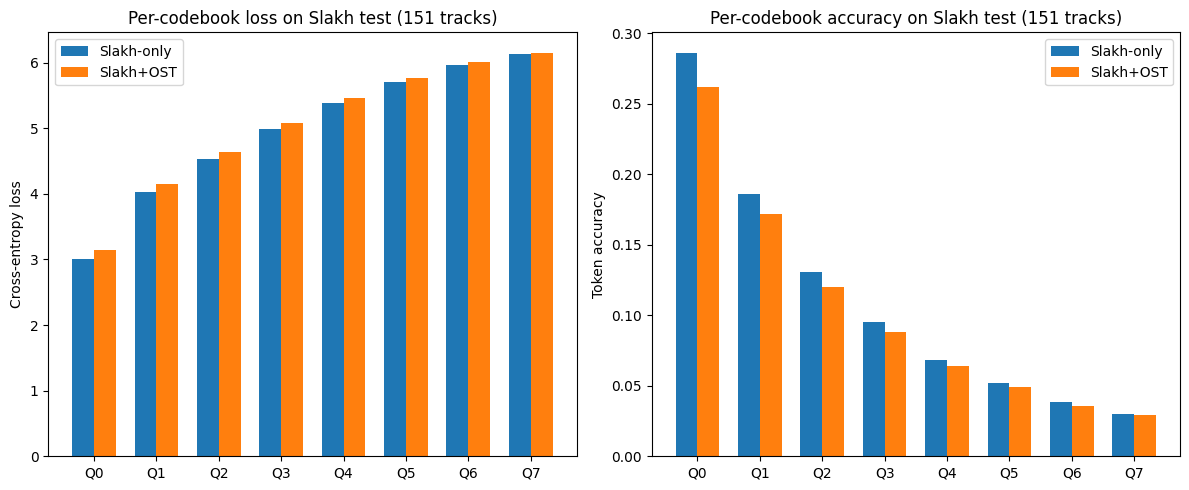

Saved figure: /kaggle/working/slakh_test_comparison.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

codebook_labels = [f"Q{q}" for q in range(NUM_CODEBOOKS)]
x = np.arange(NUM_CODEBOOKS)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: per-codebook loss
axes[0].bar(x - width/2, results_checkpoint_1["per_codebook_loss"], width, label="Slakh-only")
axes[0].bar(x + width/2, results_checkpoint_2["per_codebook_loss"], width, label="Slakh+OST")
axes[0].set_xticks(x)
axes[0].set_xticklabels(codebook_labels)
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Per-codebook loss on Slakh test (151 tracks)")
axes[0].legend()

# Right: per-codebook accuracy
axes[1].bar(x - width/2, results_checkpoint_1["per_codebook_accuracy"], width, label="Slakh-only")
axes[1].bar(x + width/2, results_checkpoint_2["per_codebook_accuracy"], width, label="Slakh+OST")
axes[1].set_xticks(x)
axes[1].set_xticklabels(codebook_labels)
axes[1].set_ylabel("Token accuracy")
axes[1].set_title("Per-codebook accuracy on Slakh test (151 tracks)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/slakh_test_comparison.png", dpi=200)
plt.show()

print("Saved figure: /kaggle/working/slakh_test_comparison.png")

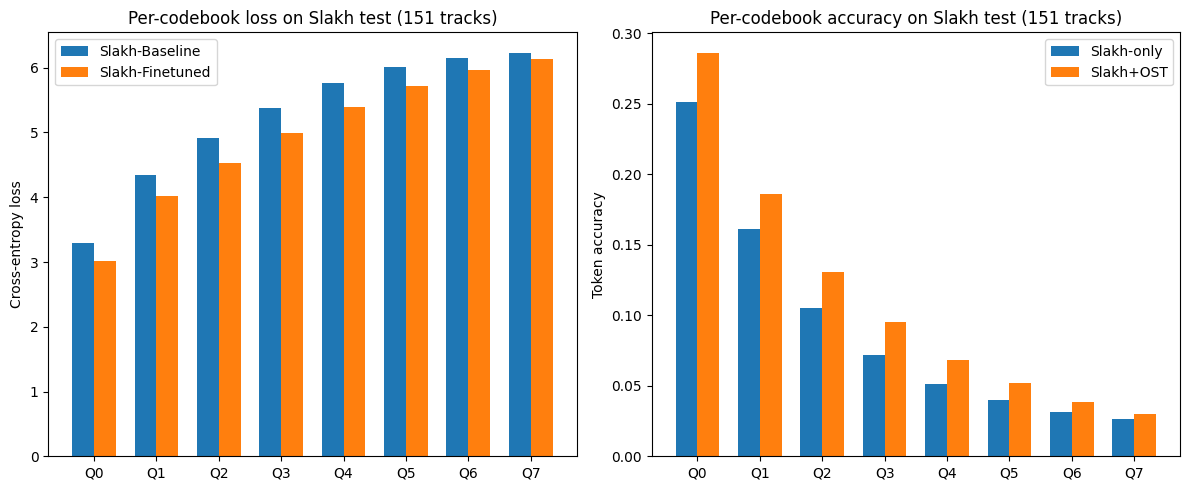

Saved figure: /kaggle/working/slakh_test_comparison_slakh_vs_slakh_finetuned.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

codebook_labels = [f"Q{q}" for q in range(NUM_CODEBOOKS)]
x = np.arange(NUM_CODEBOOKS)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: per-codebook loss
axes[0].bar(x - width/2, results_checkpoint_3["per_codebook_loss"], width, label="Slakh-Baseline")
axes[0].bar(x + width/2, results_checkpoint_1["per_codebook_loss"], width, label="Slakh-Finetuned")
axes[0].set_xticks(x)
axes[0].set_xticklabels(codebook_labels)
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Per-codebook loss on Slakh test (151 tracks)")
axes[0].legend()

# Right: per-codebook accuracy
axes[1].bar(x - width/2, results_checkpoint_3["per_codebook_accuracy"], width, label="Slakh-only")
axes[1].bar(x + width/2, results_checkpoint_1["per_codebook_accuracy"], width, label="Slakh+OST")
axes[1].set_xticks(x)
axes[1].set_xticklabels(codebook_labels)
axes[1].set_ylabel("Token accuracy")
axes[1].set_title("Per-codebook accuracy on Slakh test (151 tracks)")
axes[1].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/slakh_test_comparison_slakh_vs_slakh_finetuned.png", dpi=200)
plt.show()

print("Saved figure: /kaggle/working/slakh_test_comparison_slakh_vs_slakh_finetuned.png")